In [ ]:
import pandas as pd

from skforecast.exceptions import IgnoredArgumentWarning
from skforecast.exceptions import LongTrainingWarning

import seaborn as sns
sns.set_theme(palette="colorblind")

import warnings
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)
warnings.simplefilter('ignore', category=LongTrainingWarning)

# Non-Seasonal ARIMA

In [2]:
from sktime.datasets.forecasting import Macroeconomic

df = Macroeconomic().load()[1]
df.index = df.index.astype('datetime64[ns]')
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 203 entries, 1959-01-01 to 2009-07-01
Freq: QS-OCT
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   realgdp   203 non-null    float64
 1   realcons  203 non-null    float64
 2   realinv   203 non-null    float64
 3   realgovt  203 non-null    float64
 4   realdpi   203 non-null    float64
 5   cpi       203 non-null    float64
 6   m1        203 non-null    float64
 7   tbilrate  203 non-null    float64
 8   unemp     203 non-null    float64
 9   pop       203 non-null    float64
 10  infl      203 non-null    float64
 11  realint   203 non-null    float64
dtypes: float64(12)
memory usage: 20.6 KB


In [3]:
from sktime.transformations.series.difference import Differencer

transformer = Differencer(lags=[1])
df["infl_diff"] = transformer.fit_transform(df["infl"])

## Automatic estimation of the order of ARIMA 

In [4]:
from skforecast.stats._arima import Arima 

auto_arima = Arima(
    order=None,  # Must be None to use AutoArima
    seasonal_order = (0, 0, 0),  # use non-seasonal ARIMA
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    max_d=2,
    ic="aic",
    seasonal=False,
    test="adf",
    lambda_bc="auto",
    stepwise=False, # try all possible combinations of p, d, q up to the max values
    trace=True, # extra logging
    #optim_kwargs={"maxiter": 5000}
)
auto_arima.fit(y=df["infl_diff"], suppress_warnings=True)
auto_arima


Fitting models using approximations...

 ARIMA(p,d,q)(P,D,Q)[m]                     : aic
 ------------------------------------------------
 ARIMA(0,0,0) with zero mean     : 1025.2377
 ARIMA(0,0,0) with non-zero mean : 961.2602
 ARIMA(0,0,1) with zero mean     : 1026.7373
 ARIMA(0,0,1) with non-zero mean : 895.3617
 ARIMA(0,0,2) with zero mean     : 1001.5960
 ARIMA(0,0,2) with non-zero mean : 895.4428
 ARIMA(0,0,3) with zero mean     : 983.6213
 ARIMA(0,0,3) with non-zero mean : 895.5860
 ARIMA(0,0,4) with zero mean     : 984.8788
 ARIMA(0,0,4) with non-zero mean : 892.5166
 ARIMA(0,0,5) with zero mean     : 957.8717
 ARIMA(0,0,5) with non-zero mean : 888.8808
 ARIMA(1,0,0) with zero mean     : 1026.4768
 ARIMA(1,0,0) with non-zero mean : 913.4323
 ARIMA(1,0,1) with zero mean     : 1027.6013
 ARIMA(1,0,1) with non-zero mean : 896.0640
 ARIMA(1,0,2) with zero mean     : Inf
 ARIMA(1,0,2) with non-zero mean : 897.0392
 ARIMA(1,0,3) with zero mean     : Inf
 ARIMA(1,0,3) with non-zero 

,order,None
,seasonal_order,"(0, ...)"
,m,1
,fit_intercept,True
,enforce_stationarity,True
,method,'CSS-ML'
,n_cond,None
,optim_method,'BFGS'
,optim_kwargs,{'maxiter': 1000}
,kappa,1000000.0


In [5]:
auto_arima.summary()

ARIMA Model Summary
Model     : AutoArima(2,0,2)
Method    : Regression with ARIMA(2,0,2)(0,0,0)[1] errors
Converged : True

Coefficients:
------------------------------------------------------------
  ar1            :    -1.1030  (SE:   0.1434, t:    -7.69)
  ar2            :    -0.3055  (SE:   0.1074, t:    -2.84)
  ma1            :     0.5254  (SE:   0.1521, t:     3.45)
  ma2            :    -0.3705  (SE:   0.1104, t:    -3.35)
  intercept      :    -1.5930  (SE:   0.0705, t:   -22.59)

Model fit statistics:
  sigma^2:             4.331223
  Log-likelihood:      -437.27
  AIC:                 886.54
  BIC:                 906.42

Residual statistics:
  Mean:                0.004485
  Std Dev:             2.088690
  MAE:                 1.627549
  RMSE:                2.083543

Time Series Summary Statistics:
Number of observations: 203
  Mean:                 0.0175
  Std Dev:              2.7366
  Min:                  -11.6900
  25%:                  -1.4050
  Median:            

In [6]:
# out of sample forecast
predictions = auto_arima.predict(steps=5)
predictions

array([3.11517053e-17, 1.43183062e-01, 4.77900737e-03, 3.11517053e-17,
       3.48762906e-02])

## Backtesting

In [7]:
from skforecast.model_selection import TimeSeriesFold
from skforecast.recursive import ForecasterStats
from skforecast.model_selection._validation import backtesting_stats
from sklearn.metrics import root_mean_squared_error

cv = TimeSeriesFold(
         steps=1, # =forecast horizon
         initial_train_size=150, # size of the initial training set
         refit=True, # if true, the forecaster is refitted at each fold
         fixed_train_size=False # fixed-size or expanding training data
     )

arima_forecaster = ForecasterStats(estimator=auto_arima)

In [8]:
results_arima, predictions_backtest = backtesting_stats(
                                   forecaster=arima_forecaster,
                                   y=df["infl_diff"],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_arima.index = ["ARIMA"]

╭──────────────────────────────── LongTrainingWarning ─────────────────────────────────╮
│ The forecaster will be fit 53 times. This can take substantial amounts of time. If   │
│ not feasible, try with `refit = False`.                                              │
│                                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.LongTrainingWarning                                 │
│ Location :                                                                           │
│ c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\model_selection │
│ \_validation.py:1990                                                                 │
│ Suppress : warnings.simplefilter('ignore', category=LongTrainingWarning)             │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/53 [00:00<?, ?it/s]

c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2492: RuntimeWarning: invalid value encountered in scalar divide
  return 0.5 * (np.log(sigma2) + kf['sumlog'] / kf['nu'])
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2492: RuntimeWarning: invalid value encountered in scalar divide
  return 0.5 * (np.log(sigma2) + kf['sumlog'] / kf['nu'])
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


<Axes: >

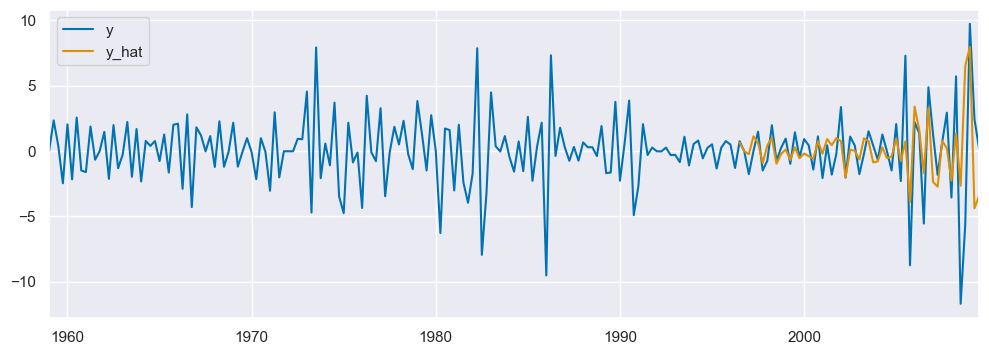

In [9]:
tdf = pd.DataFrame({"y": df['infl_diff'], "y_hat": predictions_backtest['pred']})
tdf.plot(figsize=(12,4))

## Backtesting ETS

In [10]:
# compare with ETS

from skforecast.stats._ets import Ets

ets_forecaster = ForecasterStats(estimator=Ets(model=None))

results_ets, predictions_backtest = backtesting_stats(
                                   forecaster=ets_forecaster,
                                   y=df['infl_diff'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_ets.index = ["ETS"]

╭──────────────────────────────── LongTrainingWarning ─────────────────────────────────╮
│ The forecaster will be fit 53 times. This can take substantial amounts of time. If   │
│ not feasible, try with `refit = False`.                                              │
│                                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.LongTrainingWarning                                 │
│ Location :                                                                           │
│ c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\model_selection │
│ \_validation.py:1990                                                                 │
│ Suppress : warnings.simplefilter('ignore', category=LongTrainingWarning)             │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/53 [00:00<?, ?it/s]

## Backtesting Last-Value Baseline

In [ ]:
# compare to last-value baseline

from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection._validation import backtesting_forecaster

last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results_lv, predictions_backtest = backtesting_forecaster(
                                   forecaster=last_value_forecaster,
                                   y=df['infl_diff'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_lv.index = ["Last-Value"]

╭──────────────────────────────── LongTrainingWarning ─────────────────────────────────╮
│ The forecaster will be fit 53 times. This can take substantial amounts of time. If   │
│ not feasible, try with `refit = False`.                                              │
│                                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.LongTrainingWarning                                 │
│ Location :                                                                           │
│ c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\model_selection │
│ \_validation.py:536                                                                  │
│ Suppress : warnings.simplefilter('ignore', category=LongTrainingWarning)             │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/53 [00:00<?, ?it/s]

## Results

In [12]:
results_all = pd.concat([results_arima, results_ets, results_lv], axis=0)
results_all

,root_mean_squared_error,mean_absolute_error
ARIMA,2.947693,1.824534
ETS,3.331829,2.190849
Last-Value,5.518082,3.851132


# SARIMA

In [15]:
df = pd.read_csv("tourism.csv", parse_dates=["ds"])

# sum the values across different states for the "Holiday" purpose
df = df[df["Purpose"] == "Holiday"].groupby("ds")["y"].sum().to_frame()

# explicitly set the frequency of the index to quarterly
df.index.freq = 'QS-OCT'

df.head()

,y
ds,
1998-01-01,11806.037622
1998-04-01,9275.662074
1998-07-01,8642.488590
1998-10-01,9299.523781
1999-01-01,11172.027056


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 80 entries, 1998-01-01 to 2017-10-01
Freq: QS-OCT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       80 non-null     float64
dtypes: float64(1)
memory usage: 1.2 KB


<Axes: xlabel='ds'>

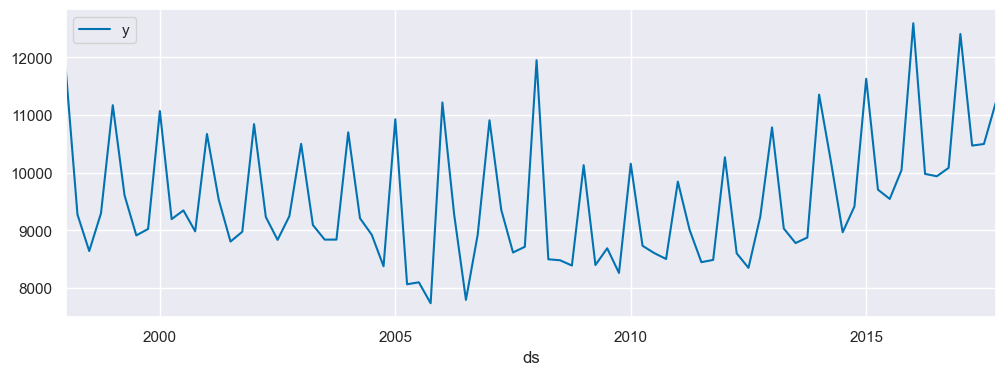

In [14]:
df.plot(figsize=(12,4))

## Backtesting

In [ ]:
cv = TimeSeriesFold(
         steps=1, # =forecast horizon
         initial_train_size=64, # size of the initial training set
         refit=True, # if true, the forecaster is refitted at each fold
         fixed_train_size=False # fixed-size or expanding training data
     )

arima_forecaster = ForecasterStats(estimator=Arima(order=None, seasonal_order=None, m=4, stepwise=False))

results_arima, predictions_backtest = backtesting_stats(
                                   forecaster=arima_forecaster,
                                   y=df["y"],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_arima.index = ["ARIMA"]

c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWa

  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWarning: Possible convergence problem. Try to increase 'maxiter' or change the optimization method.
  warnings.warn(
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\stats\arima\_arima_base.py:2542: UserWa

<Axes: >

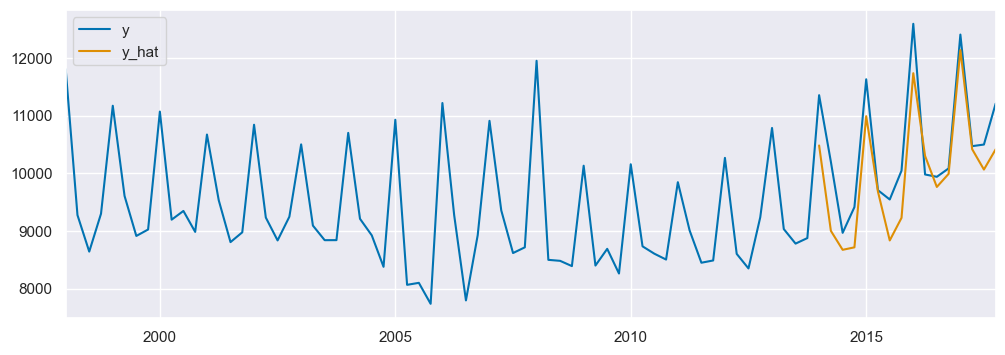

In [20]:
tdf = pd.DataFrame({"y": df['y'], "y_hat": predictions_backtest['pred']})
tdf.plot(figsize=(12,4))

## Backtesting ETS

In [21]:
# compare with ETS

from skforecast.stats._ets import Ets

ets_forecaster = ForecasterStats(estimator=Ets(model=None))

results_ets, predictions_backtest = backtesting_stats(
                                   forecaster=ets_forecaster,
                                   y=df['y'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_ets.index = ["ETS"]

  0%|          | 0/16 [00:00<?, ?it/s]

## Backtesting Last-Value Baseline

In [23]:
# compare to last-value baseline

from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection._validation import backtesting_forecaster

last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results_lv, predictions_backtest = backtesting_forecaster(
                                   forecaster=last_value_forecaster,
                                   y=df['y'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_lv.index = ["Last-Value"]

  0%|          | 0/16 [00:00<?, ?it/s]

## Results

In [24]:
results_all = pd.concat([results_arima, results_ets, results_lv], axis=0)
results_all

,root_mean_squared_error,mean_absolute_error
ARIMA,618.620887,515.861045
ETS,1332.880323,906.306131
Last-Value,1602.033389,1278.500326


# Citing this notebook
If you use this notebook in your work, please cite it as follows:

Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf